# (14) Predictive performance

host = ```any```, device = ```cuda:1```

**Motivation**:  <br>


In [1]:
# HIDE CODE


project_name = '_TemporalSC'


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, project_name))
from figures.convergence import plot_convergence
from main.config_defaults import default_configs
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
# HIDE CODE


def _add_mse_perdim(results):
    results['mse_perdim'] = 1000 * results['mse'] / np.prod(tr.model.cfg.input_sz)
    results['pred_mse_perdim'] = 1000 * results['pred_mse'] / np.prod(tr.model.cfg.input_sz)
    return


def _quick_plot_perf(results, ylim_r2, ylim_mse):
    fig, axes = create_figure(2, 2, (7, 5.4), sharex='all')

    kws = dict(lw=0.9, marker='.')


    for ax in axes[0].flat:
        ax.plot(range(1, 1000+1), results['r2'], label='r2 - posterior', **kws)
        ax.plot(range(1, 1000+1), results['pred_r2'], label='r2 - prior pred', **kws)
        ax.set(xscale='log')

    axes[0, 0].set(ylim=(0.0, 1.0))
    axes[0, 1].set(ylim=ylim_r2)
    axes[0, 0].set_ylabel(r"$R^2$")


    for ax in axes[1].flat:
        ax.plot(range(1, 1000+1), results['mse_perdim'], label='mse - posterior', **kws)
        ax.plot(range(1, 1000+1), results['pred_mse_perdim'], label='mse - prior pred', **kws)
        ax.set(xscale='log')

    # axes[0].set(ylim=(0.0, 1.0))
    axes[1, 1].set(ylim=ylim_mse)
    axes[1, 0].set_ylabel('MSE per dim  ' + r"$(\, \times \, 10^{-3} \,)$")

    add_legend(axes)
    add_grid(axes)

    plt.show()

In [3]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: chewie

## MNIST

### Load model (MNIST)

In [4]:
from analysis.final import get_list_of_fits

patterns = ['MNIST+rotate_t-(16,8,4)', 'kms-(256,8,3)', 'fwd-(3,7)']
fits, root = get_list_of_fits(patterns)
print(fits)

[
    'poisson_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(256,8,3)_fwd-(3,7)_recon-mse_dtheta-15_yoru-0_(2025_09_09,1
4:07)',
    'poisson_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(256,8,3)_fwd-(3,7)_recon-mse_no-balance-stages_chewie-0_(20
25_09_11,10:20)',
    'poisson_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(256,8,3)_fwd-(3,7)_recon-mse_no-balance-stages_chewie-0_(20
25_09_11,12:21)',
    'poisson_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-2_kms-(256,8,3)_fwd-(3,7)_recon-mse_no-balance-stages_chewie-0_(20
25_09_12,18:09)'
]

In [5]:
fit = 'poisson_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(256,8,3)_fwd-(3,7)_recon-mse_no-balance-stages_chewie-0_(2025_09_11,12:21)'
tr, meta = load_model_lite(pjoin(root, fit), device=device)
tr.print()

poisson_MNIST+rotate_t-(16,8,4)_b-1_kms-(256,8,3)_fwd-(3,7)_<ngd|lin>
b100-ep100-lr(0.0005)_temp(0.05)_gr(250)_(2025_09_11,12:21)

### xtract results

In [6]:
%%time


output_stochastic = tr.xtract_ftr(data_batch_sz=1_000, n_data_batches=-1)

tr.model.cfg.stochastic = False
tr.model.layer.cfg.stochastic = False

output_deterministic = tr.xtract_ftr(data_batch_sz=1_000, n_data_batches=-1)

batch #10, (t = 1000): 100%|██████████| 10/10 [01:51<00:00, 11.14s/it]

CPU times: user 3min 40s, sys: 1.6 s, total: 3min 41s
Wall time: 3min 39s


In [7]:
_add_mse_perdim(output_stochastic)
_add_mse_perdim(output_deterministic)

### plot results

results: stochastic

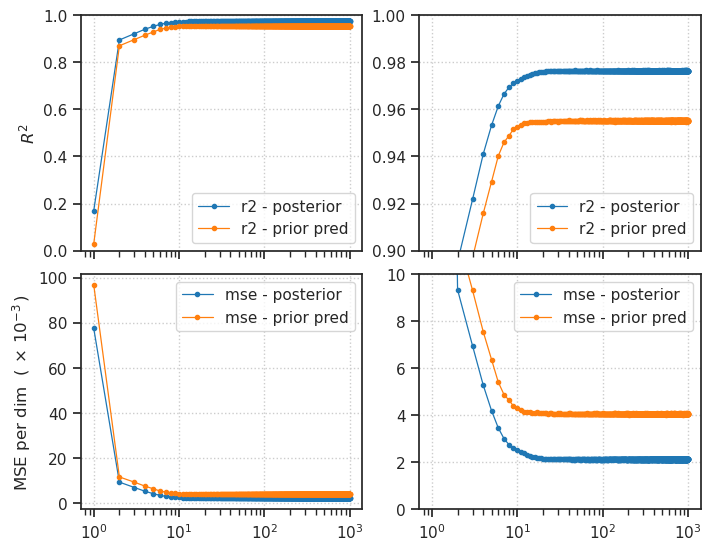

In [8]:
print('results: stochastic')
_quick_plot_perf(output_stochastic, ylim_r2=(0.9, 1.0), ylim_mse=(0, 10))

results: deterministic

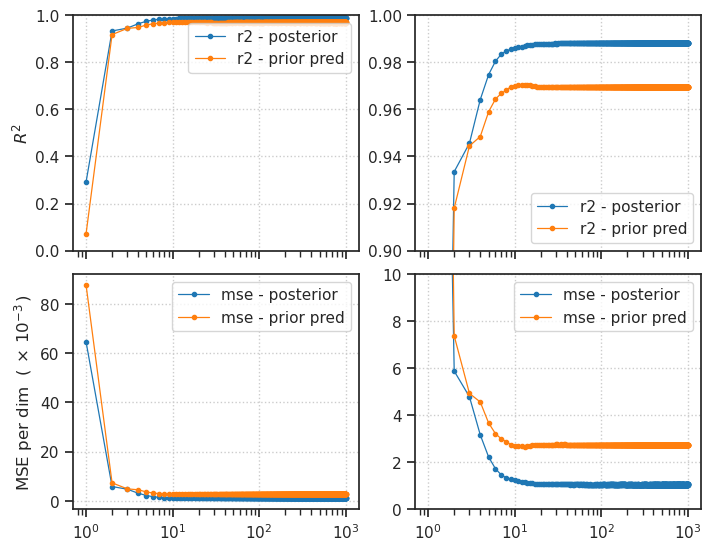

In [9]:
print('results: deterministic')
_quick_plot_perf(output_deterministic, ylim_r2=(0.9, 1.0), ylim_mse=(0, 10))

In [10]:
msg = ', '.join([
    f"sotchastic      —>   r2 = {output_stochastic['pred_r2'][-1]:0.3f}",
    f"mse_perdim = {output_stochastic['pred_mse_perdim'][-1]:0.3f}",
    f"\ndeterministic   —>   r2 = {output_deterministic['pred_r2'][-1]:0.3f}",
    f"mse_perdim = {output_deterministic['pred_mse_perdim'][-1]:0.3f}",
])
msg = f"MNIST pred results:\n\n{msg}\n"

print(msg)


msg = ', '.join([
    f"sotchastic      —>   r2 = {output_stochastic['r2'][-1]:0.3f}",
    f"mse_perdim = {output_stochastic['mse_perdim'][-1]:0.3f}",
    f"\ndeterministic   —>   r2 = {output_deterministic['r2'][-1]:0.3f}",
    f"mse_perdim = {output_deterministic['mse_perdim'][-1]:0.3f}",
])
msg = f"MNIST recon results:\n\n{msg}\n"

print(msg)

MNIST pred results:

sotchastic      —>   r2 = 0.955, mse_perdim = 4.054, 
deterministic   —>   r2 = 0.970, mse_perdim = 2.728

MNIST recon results:

sotchastic      —>   r2 = 0.976, mse_perdim = 2.110, 
deterministic   —>   r2 = 0.988, mse_perdim = 1.044

### sanity check for the loaded model

In [11]:
from analysis.final import get_root_path

# fit = 'poisson_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(256,8,3)_fwd-(3,7)_recon-mse_no-balance-stages_chewie-0_(2025_09_11,12:21)'
tr, meta = load_model_lite(pjoin(get_root_path(), fit), device=device)
tr.print()

poisson_MNIST+rotate_t-(16,8,4)_b-1_kms-(256,8,3)_fwd-(3,7)_<ngd|lin>
b100-ep100-lr(0.0005)_temp(0.05)_gr(250)_(2025_09_11,12:21)

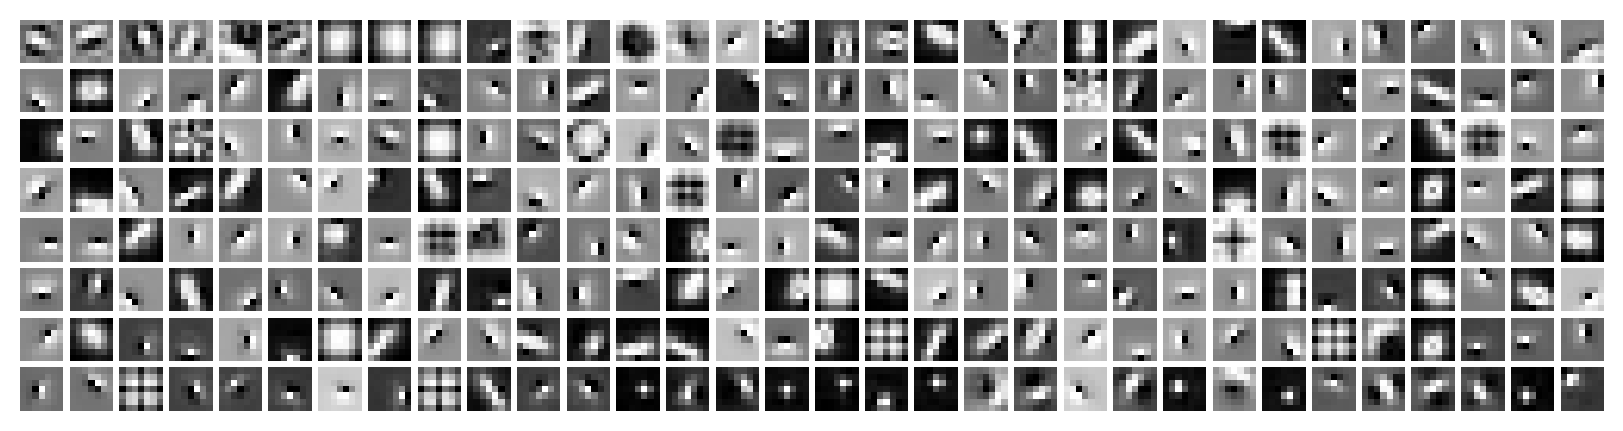

In [12]:
tr.model.show(order='u0');

In [13]:
dt_str = '\n'.join([
    f"dt_enc = {tr.model.layer.log_dt_enc[0].exp().item():0.3f}",
    f"dt_fwd = {tr.model.layer.log_dt_fwd[0].exp().item():0.3f}",
])
print(dt_str)

dt_enc = 0.335
dt_fwd = 1.092

batch #10, (t = 1000): 100%|██████████| 10/10 [01:56<00:00, 11.69s/it]


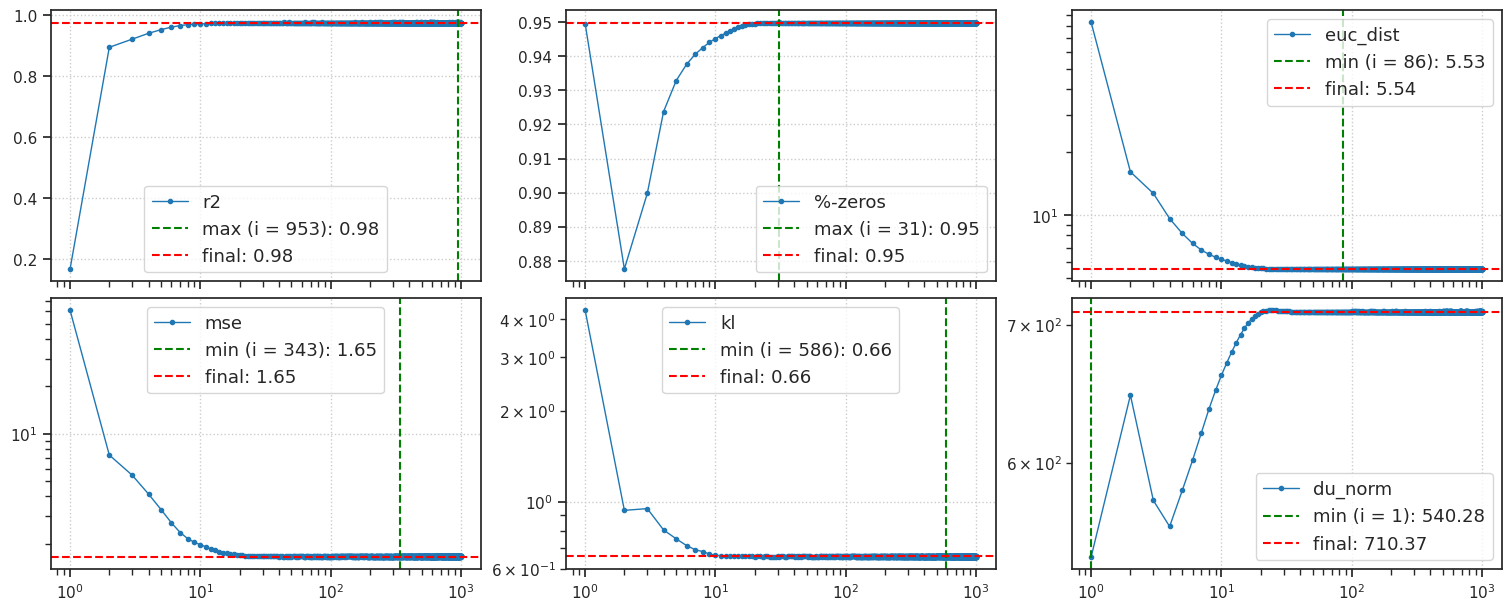

CPU times: user 1min 58s, sys: 1.27 s, total: 1min 59s
Wall time: 1min 57s


In [14]:
%%time

results = tr.analysis('vld', t_total=1000, data_batch_sz=1_000, n_data_batches=-1)
_ = plot_convergence(results=results, color='C0')

## Kyoto

### Load model (Kyoto)

In [15]:
from analysis.final import get_list_of_fits

patterns = ['Kyoto-wht+translate_t-(16,8,4)', 'kms-(512,9,3)', 'fwd-(3,7)']
fits, root = get_list_of_fits(patterns)
print(fits)

[
    'poisson_<ngd|lin>_Kyoto-wht+translate_t-(16,8,4)_b-2_kms-(512,9,3)_fwd-(3,7)_recon-mse_no-balance-stages_mach-
0_(2025_09_11,12:28)'
]

In [16]:
fit = 'poisson_<ngd|lin>_Kyoto-wht+translate_t-(16,8,4)_b-2_kms-(512,9,3)_fwd-(3,7)_recon-mse_no-balance-stages_mach-0_(2025_09_11,12:28)'
tr, meta = load_model_lite(pjoin(root, fit), device=device)
tr.print()

poisson_Kyoto-wht+translate_t-(16,8,4)_b-2_kms-(512,9,3)_fwd-(3,7)_<ngd|lin>
b100-ep300-lr(0.0005)_temp(0.05)_gr(500)_(2025_09_11,12:28)

### xtract results

In [17]:
%%time


output_stochastic = tr.xtract_ftr(data_batch_sz=2_000, n_data_batches=5)

tr.model.cfg.stochastic = False
tr.model.layer.cfg.stochastic = False

output_deterministic = tr.xtract_ftr(data_batch_sz=2_000, n_data_batches=5)

batch #5, (t = 1000): 100%|█████████████| 5/5 [07:45<00:00, 93.20s/it]

CPU times: user 15min 14s, sys: 1.05 s, total: 15min 15s
Wall time: 15min 14s


In [18]:
_add_mse_perdim(output_stochastic)
_add_mse_perdim(output_deterministic)

### plot results

results: stochastic

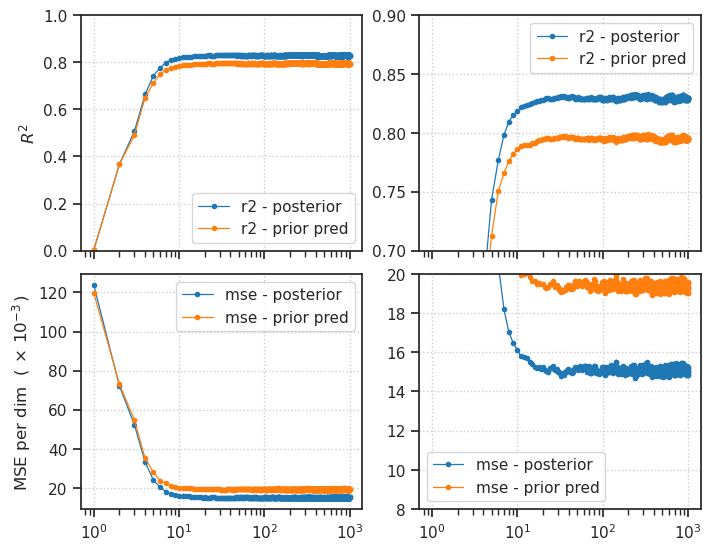

results: deterministic

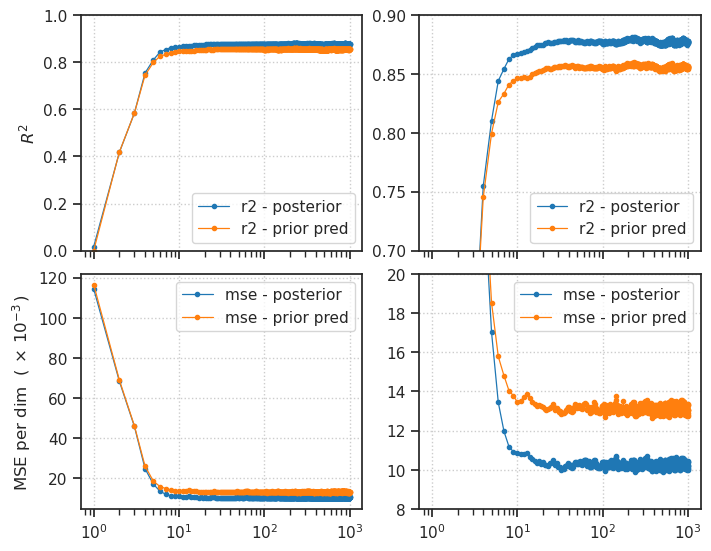

In [19]:
kws = dict(ylim_r2=(0.7, 0.9), ylim_mse = (8.0, 20.0))

print('results: stochastic')
_quick_plot_perf(output_stochastic, **kws)

print('results: deterministic')
_quick_plot_perf(output_deterministic, **kws)

In [20]:
msg = ', '.join([
    f"sotchastic      —>   r2 = {output_stochastic['pred_r2'][-1]:0.3f}",
    f"mse_perdim = {output_stochastic['pred_mse_perdim'][-1]:0.3f}",
    f"\ndeterministic   —>   r2 = {output_deterministic['pred_r2'][-1]:0.3f}",
    f"mse_perdim = {output_deterministic['pred_mse_perdim'][-1]:0.3f}",
])
msg = f"Kyoto pred results:\n\n{msg}\n"

print(msg)


msg = ', '.join([
    f"sotchastic      —>   r2 = {output_stochastic['r2'][-1]:0.3f}",
    f"mse_perdim = {output_stochastic['mse_perdim'][-1]:0.3f}",
    f"\ndeterministic   —>   r2 = {output_deterministic['r2'][-1]:0.3f}",
    f"mse_perdim = {output_deterministic['mse_perdim'][-1]:0.3f}",
])
msg = f"Kyoto recon results:\n\n{msg}\n"

print(msg)

Kyoto pred results:

sotchastic      —>   r2 = 0.794, mse_perdim = 19.595, 
deterministic   —>   r2 = 0.855, mse_perdim = 13.339

Kyoto recon results:

sotchastic      —>   r2 = 0.828, mse_perdim = 15.263, 
deterministic   —>   r2 = 0.876, mse_perdim = 10.445

### sanity check for the loaded model

In [21]:
from analysis.final import get_root_path

tr, meta = load_model_lite(pjoin(get_root_path(), fit), device=device)
tr.print()

poisson_Kyoto-wht+translate_t-(16,8,4)_b-2_kms-(512,9,3)_fwd-(3,7)_<ngd|lin>
b100-ep300-lr(0.0005)_temp(0.05)_gr(500)_(2025_09_11,12:28)

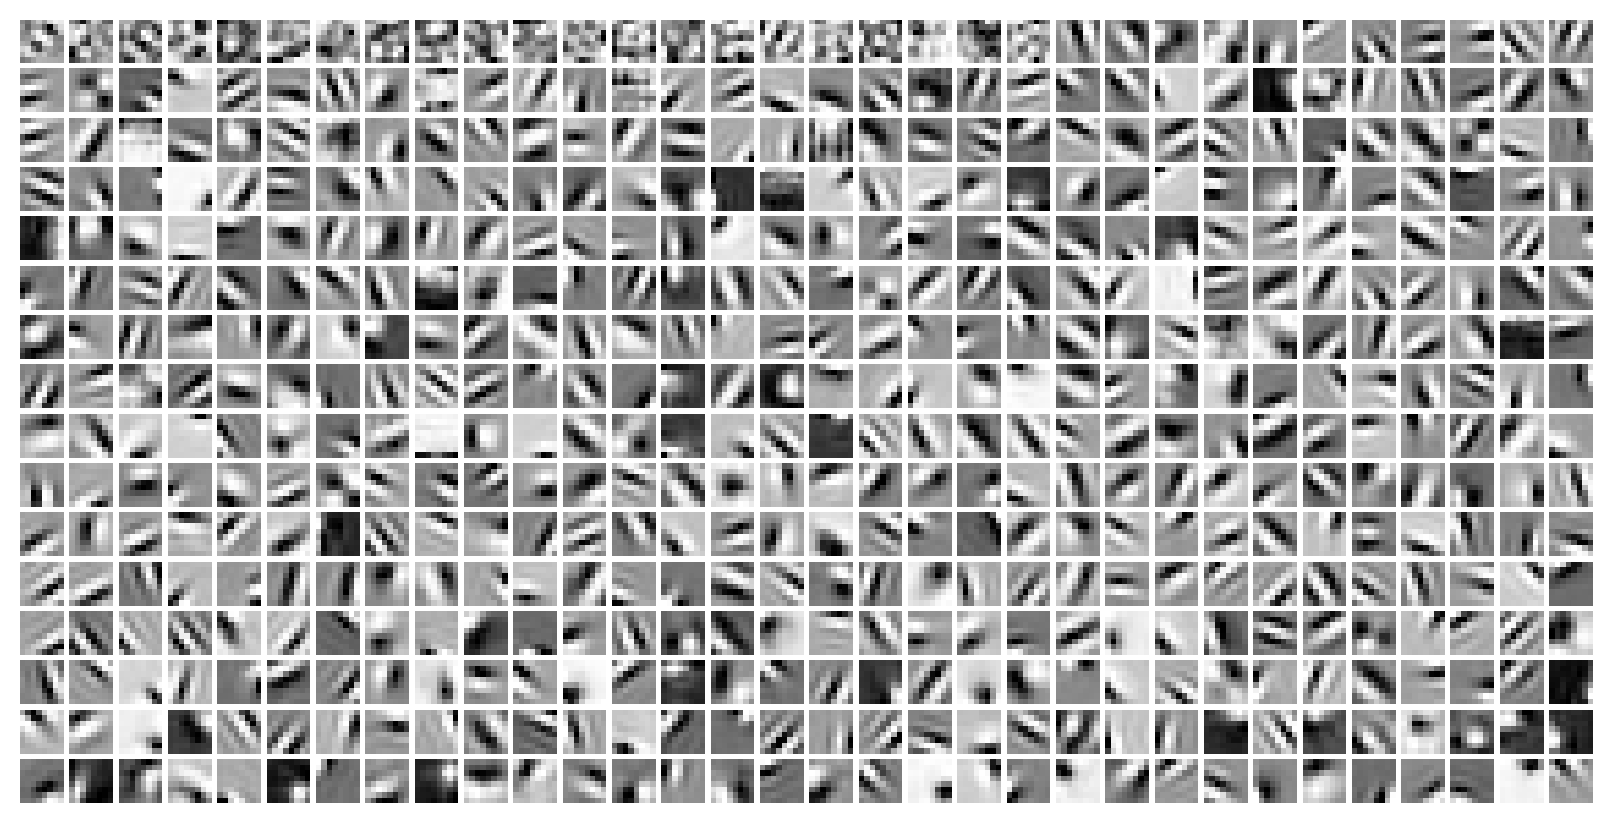

In [22]:
tr.model.show(order='u0');

In [23]:
dt_str = '\n'.join([
    f"dt_enc = {tr.model.layer.log_dt_enc[0].exp().item():0.3f}",
    f"dt_fwd = {tr.model.layer.log_dt_fwd[0].exp().item():0.3f}",
])
print(dt_str)

dt_enc = 0.311
dt_fwd = 0.659

batch #50, (t = 1000): 100%|████████| 50/50 [1:17:41<00:00, 93.22s/it]


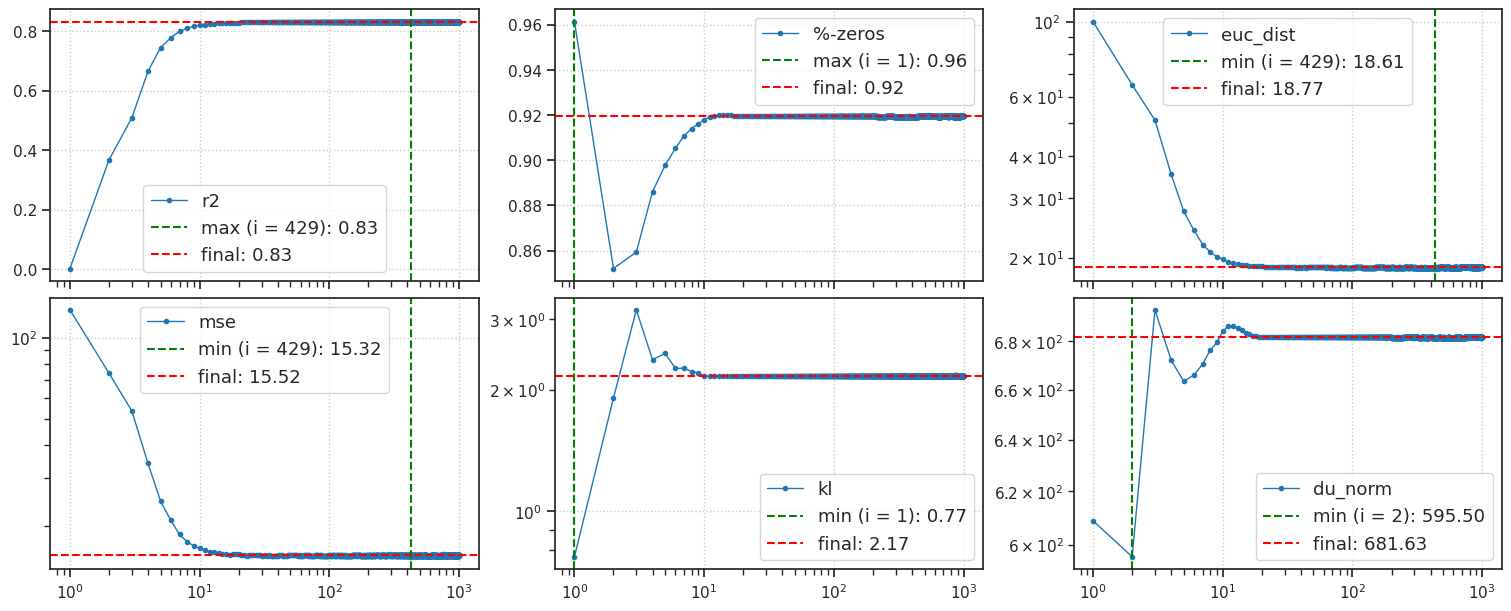

CPU times: user 1h 17min 35s, sys: 13.7 s, total: 1h 17min 49s
Wall time: 1h 17min 41s


In [24]:
%%time

results = tr.analysis('vld', t_total=1000, data_batch_sz=2_000, n_data_batches=50)
_ = plot_convergence(results=results, color='C0')